**SVM Assignment-10**

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, r2_score
from sklearn.preprocessing import StandardScaler

In [31]:
df = pd.read_csv('/content/Pharma_Industry.csv')

In [32]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [33]:
df.shape

(500, 6)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [35]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [36]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


Visualization

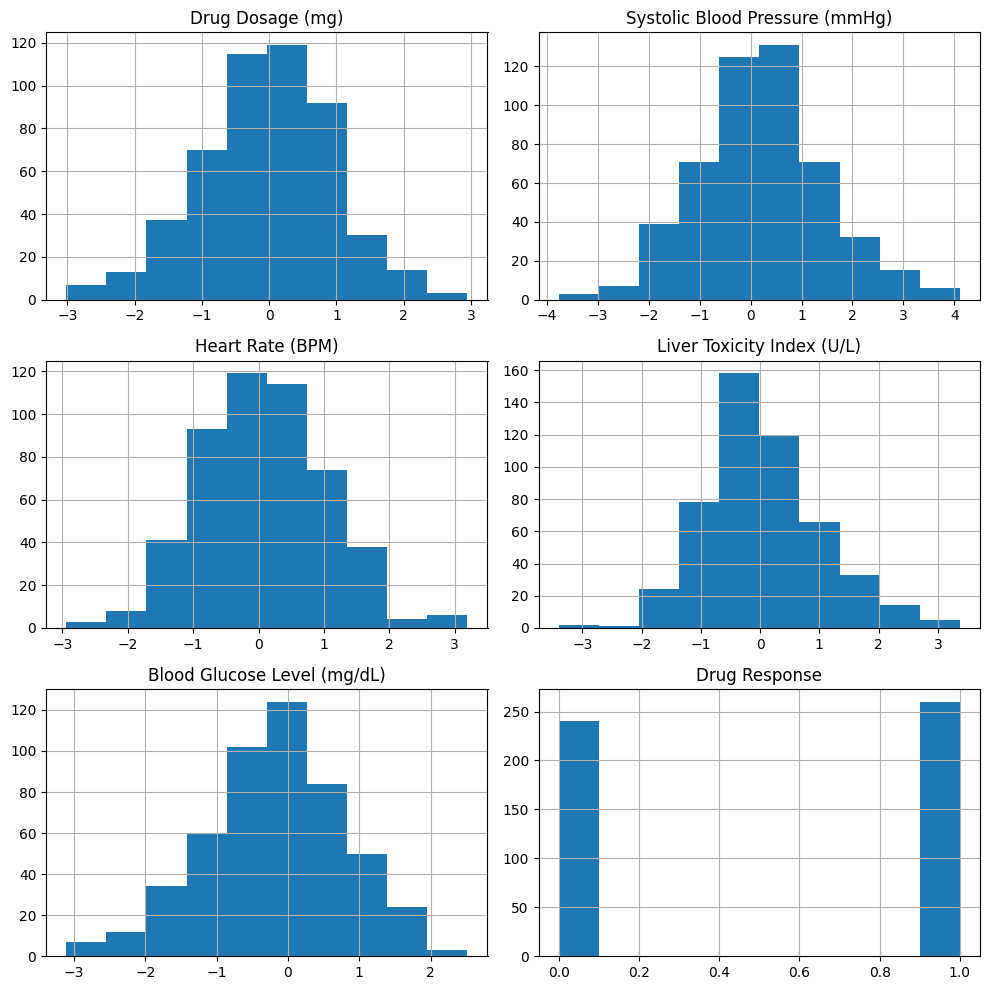

In [39]:
df.hist(figsize=(10,10))
plt.tight_layout()
plt.show()

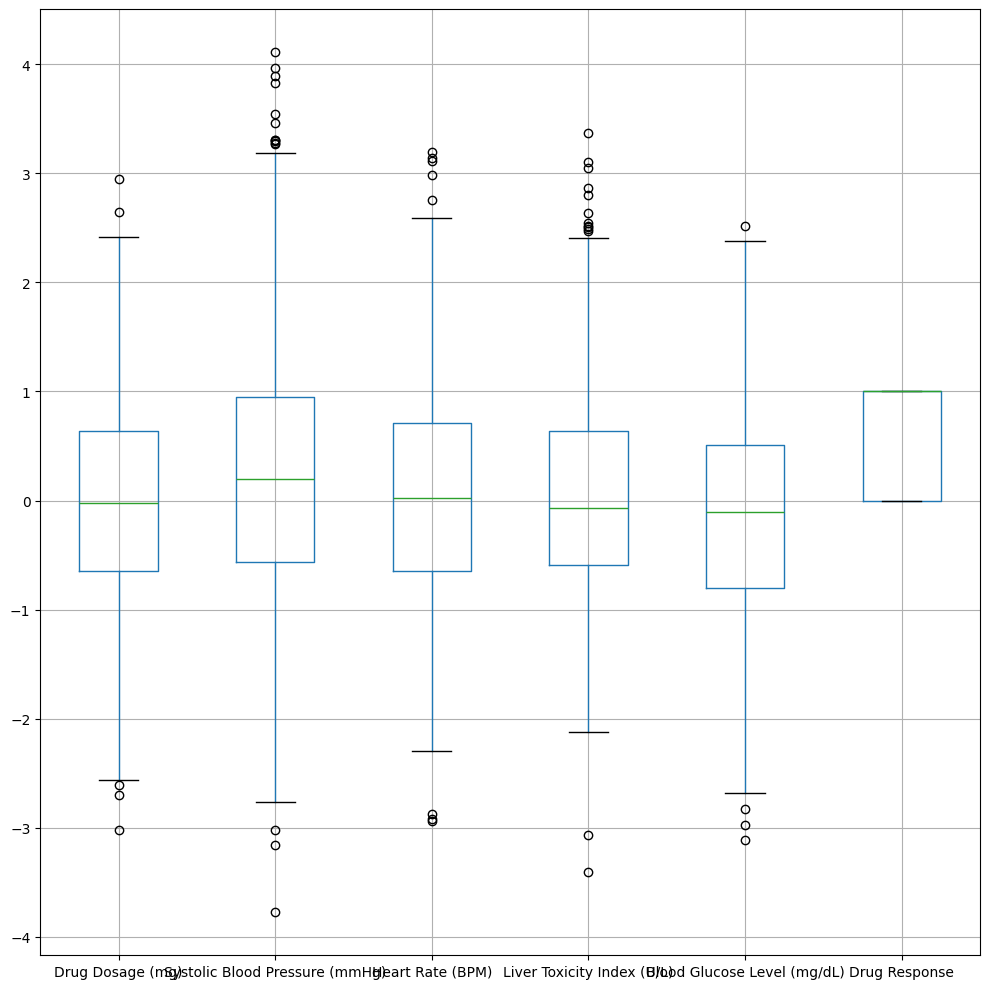

In [40]:
df.boxplot(figsize=(10,10))
plt.tight_layout()
plt.show()

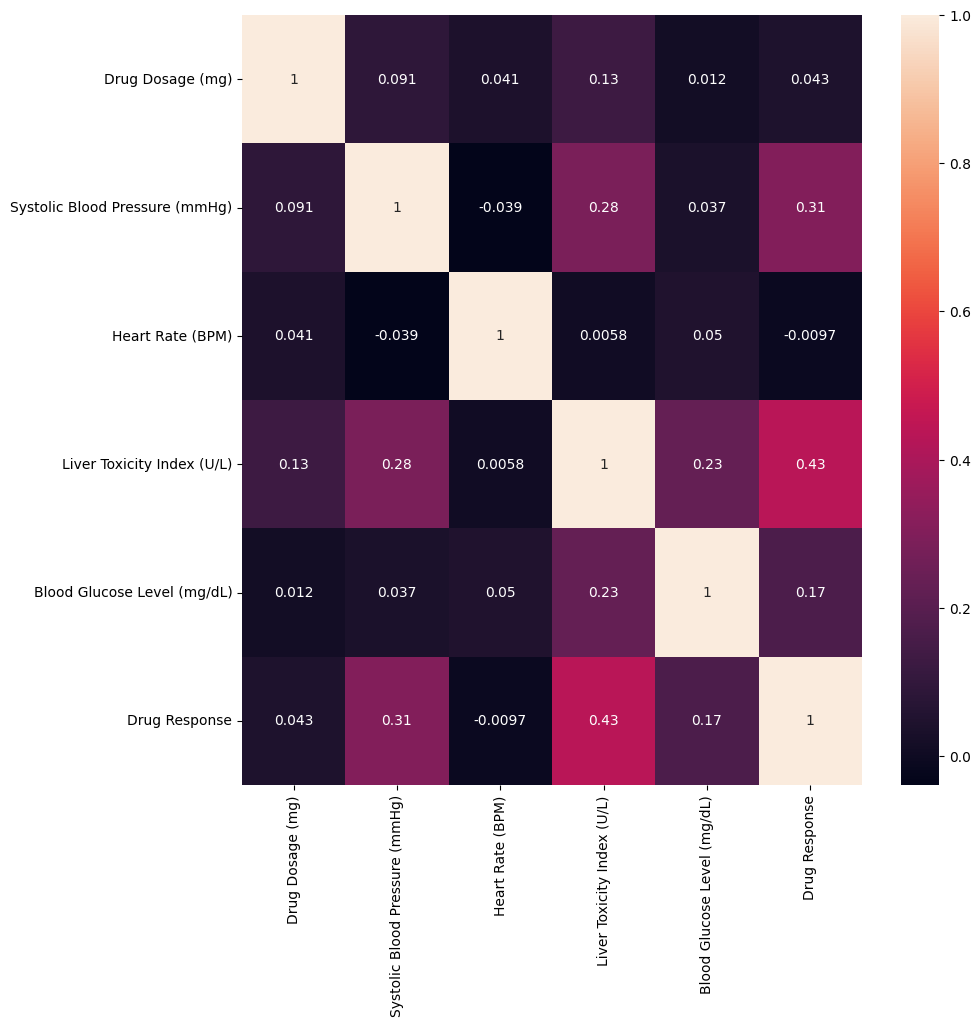

In [41]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [42]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


In [51]:
X =df.drop('Drug Response',axis=1)
y =df['Drug Response']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

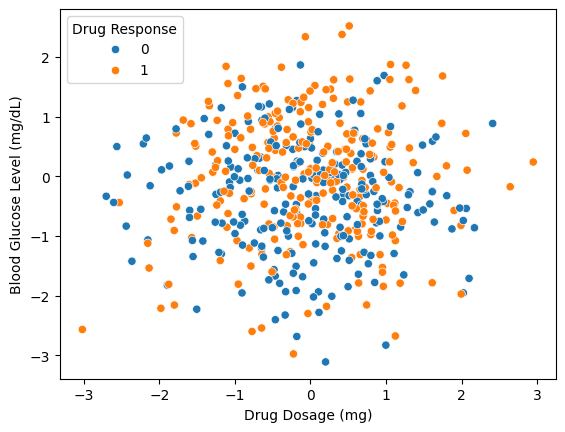

In [58]:
sns.scatterplot(x='Drug Dosage (mg)', y='Blood Glucose Level (mg/dL)', hue='Drug Response', data=df)
plt.show()

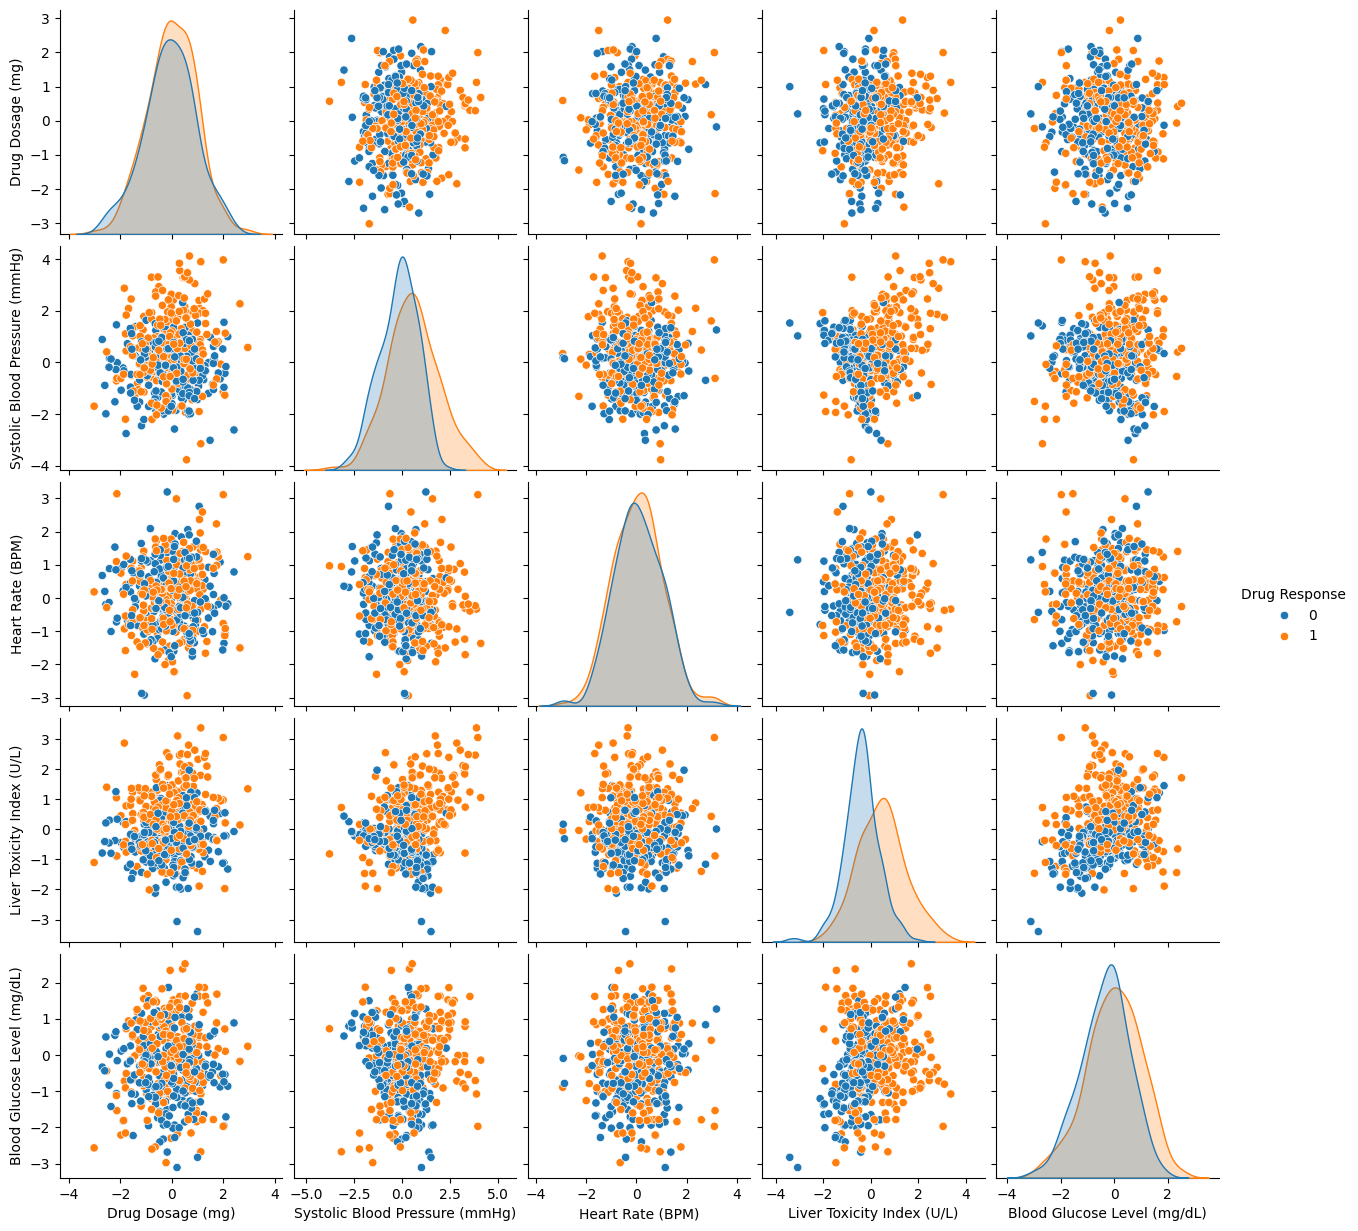

In [59]:
sns.pairplot(df,hue='Drug Response')
plt.show()

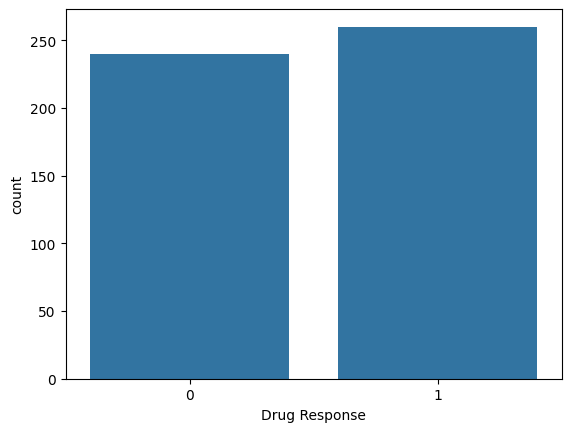

In [55]:
sns.countplot(x='Drug Response',data=df)
plt.show()

In [63]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [64]:
y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print('Accuracy Score:',accuracy_score(y_test,y_pred))
print('Precision Score:',precision_score(y_test,y_pred))
print('Recall Score:',recall_score(y_test,y_pred))
print('F1 Score:',f1_score(y_test,y_pred))

Accuracy Score: 0.78
Precision Score: 0.84
Recall Score: 0.75
F1 Score: 0.7924528301886793


In [68]:
y_test
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1])

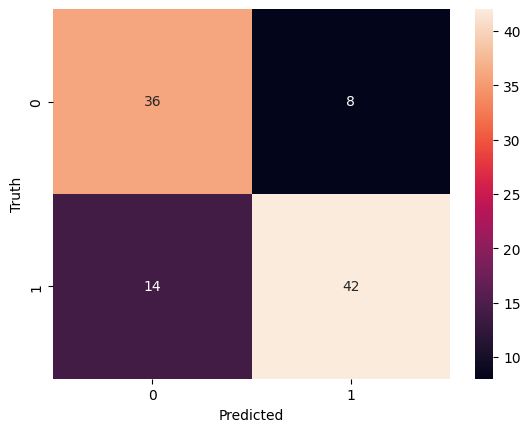

In [70]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [72]:
'linear'
'rbf'
'poly'

'poly'

In [78]:
from sklearn.svm import SVC

model_linear = SVC(kernel='linear', C=1)

model_poly = SVC(kernel='poly', C=1)

model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

print("Poly Accuracy:", accuracy_score(y_test, y_pred_poly))

Poly Accuracy: 0.69


In [80]:
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10]
}

In [81]:
param_grid

{'kernel': ['linear', 'poly', 'rbf'], 'C': [0.1, 1, 10]}

In [85]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=3
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.637 total time=   0.0s
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.762 total time=   0.0s
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.713 total time=   0.0s
[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.662 total time=   0.0s
[CV 5/5] END ..............C=0.1, kernel=linear;, score=0.700 total time=   0.0s
[CV 1/5] END ................C=0.1, kernel=poly;, score=0.625 total time=   0.0s
[CV 2/5] END ................C=0.1, kernel=poly;, score=0.700 total time=   0.0s
[CV 3/5] END ................C=0.1, kernel=poly;, score=0.650 total time=   0.0s
[CV 4/5] END ................C=0.1, kernel=poly;, score=0.613 total time=   0.0s
[CV 5/5] END ................C=0.1, kernel=poly;, score=0.662 total time=   0.0s
[CV 1/5] END .................C=0.1, kernel=rbf;, score=0.637 total time=   0.0s
[CV 2/5] END .................C=0.1, kernel=rbf;,

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'poly', 'rbf']},
             verbose=3)

In [86]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best Score: 0.7375


In [89]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model_linear = SVC(kernel='linear',C=1)
model_linear.fit(X_train,y_train)
y_pred_linear = model_linear.predict(X_test)
print("Linear Accuracy:",accuracy_score(y_test,y_pred_linear))

Linear Accuracy: 0.78


In [96]:
model_poly =SVC(kernel='poly',C=1)
model_poly.fit(X_train,y_train)
y_pred_poly = model_poly.predict(X_test)
print("Poly Accuracy:",accuracy_score(y_test,y_pred_poly))

Poly Accuracy: 0.69


In [97]:
model_rbf =SVC(kernel='rbf',C=1)
model_rbf.fit(X_train,y_train)
y_pred_rbf = model_rbf.predict(X_test)
print("RBF Accuracy:",accuracy_score(y_test,y_pred_rbf))

RBF Accuracy: 0.82


In [98]:
'linear'
'rbf'
'poly'

'poly'

Strengths:

SVM performed well on this dataset.
The RBF kernel achieved the highest accuracy (82%).
The dataset is approximately balanced, which is suitable for classification.

Weaknesses:

SVM performance depends on the kernel and hyperparameters such as C.
Different kernels produced different results.

SVM can be used for real-world classification problems.

It can classify data into different classes, such as Drug Response (0 or 1).

The RBF kernel is useful when the relationship between features and the target is non-linear.